In [ ]:
# import thư viện, kiểm tra môi trường
from pathlib import Path
import sys

print("Python:", sys.version)
print("Working directory:", Path.cwd())

Python: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Working directory: d:\httm-drowning_detection\notebooks


In [ ]:
# đọc file csv
import pandas as pd

CSV_PATH = "../runs/tracking_data/vdgocrong_bytetrack.csv"

df = pd.read_csv(CSV_PATH)

print("Đọc CSV thành công!")
print("Số dòng, số cột:", df.shape)

print("\nCác cột:")
print(df.columns.tolist())

print("\n5 dòng đầu tiên:")
display(df.head())

Đọc CSV thành công!
Số dòng, số cột: (14, 9)

Các cột:
['frame', 'track_id', 'class_id', 'class_name', 'confidence', 'x1', 'y1', 'x2', 'y2']

5 dòng đầu tiên:


,frame,track_id,class_id,class_name,confidence,x1,y1,x2,y2
0,7,1,2,Swimming,0.613482,100.464432,28.476879,1355.480591,1119.698120
1,8,1,2,Swimming,0.587396,88.258293,17.395962,1367.271729,1129.040649
2,9,1,2,Swimming,0.746949,58.947262,10.699468,1377.247925,1155.960815
3,10,1,2,Swimming,0.692327,33.379314,7.587029,1392.364624,1188.058838
4,11,1,2,Swimming,0.665187,32.507469,9.333964,1372.716797,1170.665161


In [ ]:
# kiểm tra kiểu dữ liệu
print("Thông tin dữ liệu:")
print(df.info())

print("\nSố track ID:")
print(df["track_id"].nunique())

print("\nCác track ID:")
print(df["track_id"].unique())

print("\nCác class:")
print(df["class_name"].unique())

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   frame       14 non-null     int64  
 1   track_id    14 non-null     int64  
 2   class_id    14 non-null     int64  
 3   class_name  14 non-null     object 
 4   confidence  14 non-null     float64
 5   x1          14 non-null     float64
 6   y1          14 non-null     float64
 7   x2          14 non-null     float64
 8   y2          14 non-null     float64
dtypes: float64(5), int64(3), object(1)
memory usage: 1.1+ KB
None

Số track ID:
1

Các track ID:
[1]

Các class:
['Swimming']


In [ ]:
# tính tâm bounding box
df["cx"] = (df["x1"] + df["x2"]) / 2
df["cy"] = (df["y1"] + df["y2"]) / 2

print("Đã tính tâm bounding box!")

display(
    df[
        [
            "frame",
            "track_id",
            "class_name",
            "confidence",
            "cx",
            "cy"
        ]
    ].head()
)

Đã tính tâm bounding box!


,frame,track_id,class_name,confidence,cx,cy
0,7,1,Swimming,0.613482,727.972511,574.087500
1,8,1,Swimming,0.587396,727.765011,573.218306
2,9,1,Swimming,0.746949,718.097593,583.330142
3,10,1,Swimming,0.692327,712.871969,597.822934
4,11,1,Swimming,0.665187,702.612133,589.999563


In [ ]:
# track history
for track_id in df["track_id"].unique():

    track = df[df["track_id"] == track_id].copy()

    print(f"\nTrack ID: {track_id}")
    print(f"Số frame: {len(track)}")

    display(
        track[
            [
                "frame",
                "track_id",
                "class_name",
                "confidence",
                "cx",
                "cy"
            ]
        ].head(10)
    )


Track ID: 1
Số frame: 14


,frame,track_id,class_name,confidence,cx,cy
0,7,1,Swimming,0.613482,727.972511,574.087500
1,8,1,Swimming,0.587396,727.765011,573.218306
2,9,1,Swimming,0.746949,718.097593,583.330142
3,10,1,Swimming,0.692327,712.871969,597.822934
4,11,1,Swimming,0.665187,702.612133,589.999563
5,12,1,Swimming,0.610489,700.363384,593.060481
6,13,1,Swimming,0.392481,694.402300,615.131004
7,15,1,Swimming,0.480084,677.188423,620.363060
8,16,1,Swimming,0.456207,673.282043,622.637440
9,17,1,Swimming,0.389126,666.600708,632.535074


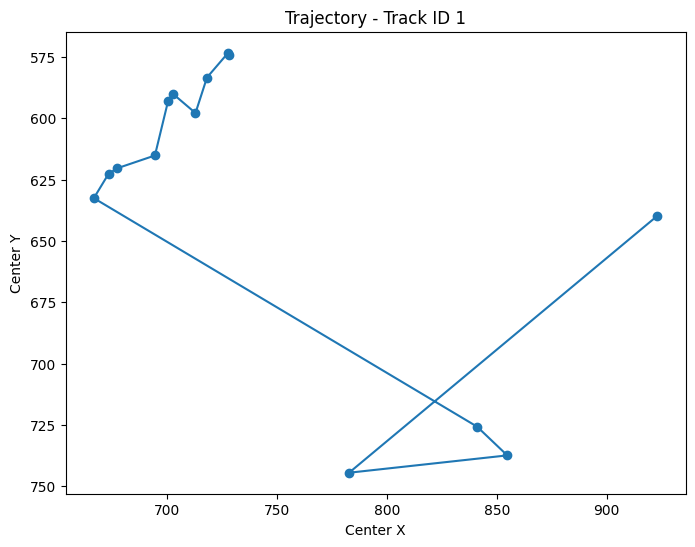

In [ ]:
# vẽ trajectory
import matplotlib.pyplot as plt

track_id = 1

track = df[df["track_id"] == track_id].copy()

plt.figure(figsize=(8, 6))

plt.plot(
    track["cx"],
    track["cy"],
    marker="o"
)

plt.xlabel("Center X")
plt.ylabel("Center Y")
plt.title(f"Trajectory - Track ID {track_id}")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# tính movement
df["dx"] = df.groupby("track_id")["cx"].diff()
df["dy"] = df.groupby("track_id")["cy"].diff()

df["movement"] = (
    df["dx"] ** 2 + df["dy"] ** 2
) ** 0.5

display(
    df[
        [
            "frame",
            "track_id",
            "cx",
            "cy",
            "dx",
            "dy",
            "movement"
        ]
    ]
)

,frame,track_id,cx,cy,dx,dy,movement
0,7,1,727.972511,574.087500,NaN,NaN,NaN
1,8,1,727.765011,573.218306,-0.207500,-0.869194,0.893619
2,9,1,718.097593,583.330142,-9.667418,10.111836,13.989574
3,10,1,712.871969,597.822934,-5.225624,14.492792,15.406108
4,11,1,702.612133,589.999563,-10.259836,-7.823371,12.902301
5,12,1,700.363384,593.060481,-2.248749,3.060918,3.798170
6,13,1,694.402300,615.131004,-5.961084,22.070523,22.861376
7,15,1,677.188423,620.363060,-17.213877,5.232056,17.991442
8,16,1,673.282043,622.637440,-3.906379,2.274380,4.520244
9,17,1,666.600708,632.535074,-6.681335,9.897635,11.941667


In [ ]:
# tính velocity
df["velocity"] = df["movement"]

display(
    df[
        [
            "frame",
            "track_id",
            "movement",
            "velocity"
        ]
    ]
)

,frame,track_id,movement,velocity
0,7,1,NaN,NaN
1,8,1,0.893619,0.893619
2,9,1,13.989574,13.989574
3,10,1,15.406108,15.406108
4,11,1,12.902301,12.902301
5,12,1,3.798170,3.798170
6,13,1,22.861376,22.861376
7,15,1,17.991442,17.991442
8,16,1,4.520244,4.520244
9,17,1,11.941667,11.941667


In [ ]:
# xác định direction
def get_direction(dx, dy):

    if pd.isna(dx) or pd.isna(dy):
        return "Unknown"

    if abs(dx) < 1 and abs(dy) < 1:
        return "Stationary"

    if abs(dx) > abs(dy):
        if dx > 0:
            return "Right"
        else:
            return "Left"

    else:
        if dy > 0:
            return "Down"
        else:
            return "Up"


df["direction"] = df.apply(
    lambda row: get_direction(row["dx"], row["dy"]),
    axis=1
)

display(
    df[
        [
            "frame",
            "track_id",
            "dx",
            "dy",
            "movement",
            "direction"
        ]
    ]
)

,frame,track_id,dx,dy,movement,direction
0,7,1,NaN,NaN,NaN,Unknown
1,8,1,-0.207500,-0.869194,0.893619,Stationary
2,9,1,-9.667418,10.111836,13.989574,Down
3,10,1,-5.225624,14.492792,15.406108,Down
4,11,1,-10.259836,-7.823371,12.902301,Left
5,12,1,-2.248749,3.060918,3.798170,Down
6,13,1,-5.961084,22.070523,22.861376,Down
7,15,1,-17.213877,5.232056,17.991442,Left
8,16,1,-3.906379,2.274380,4.520244,Left
9,17,1,-6.681335,9.897635,11.941667,Down


In [ ]:
# tổng hợp hành vi theo track
behavior_summary = (
    df.groupby("track_id")
    .agg(
        total_frames=("frame", "count"),
        avg_movement=("movement", "mean"),
        max_movement=("movement", "max"),
        avg_velocity=("velocity", "mean"),
        class_name=("class_name", "last")
    )
    .reset_index()
)

display(behavior_summary)

,track_id,total_frames,avg_movement,max_movement,avg_velocity,class_name
0,1,14,43.668551,197.78345,43.668551,Swimming


In [ ]:
# phân tích theo thời gian
for track_id in df["track_id"].unique():

    track = df[df["track_id"] == track_id].copy()

    print(f"\n===== Track ID {track_id} =====")

    display(
        track[
            [
                "frame",
                "class_name",
                "confidence",
                "movement",
                "velocity",
                "direction"
            ]
        ]
    )


===== Track ID 1 =====


,frame,class_name,confidence,movement,velocity,direction
0,7,Swimming,0.613482,NaN,NaN,Unknown
1,8,Swimming,0.587396,0.893619,0.893619,Stationary
2,9,Swimming,0.746949,13.989574,13.989574,Down
3,10,Swimming,0.692327,15.406108,15.406108,Down
4,11,Swimming,0.665187,12.902301,12.902301,Left
5,12,Swimming,0.610489,3.798170,3.798170,Down
6,13,Swimming,0.392481,22.861376,22.861376,Down
7,15,Swimming,0.480084,17.991442,17.991442,Left
8,16,Swimming,0.456207,4.520244,4.520244,Left
9,17,Swimming,0.389126,11.941667,11.941667,Down


In [ ]:
# đếm class theo từng track
class_history = (
    df.groupby(["track_id", "class_name"])
    .size()
    .reset_index(name="frame_count")
)

display(class_history)

,track_id,class_name,frame_count
0,1,Swimming,14


In [ ]:
# drowning decision
def drowning_decision(row):

    if row["class_name"] == "Drowning":
        return "DROWNING"

    elif row["class_name"] == "Person out of water":
        return "PERSON OUT OF WATER"

    else:
        return "NORMAL"


df["drowning_status"] = df.apply(
    drowning_decision,
    axis=1
)

display(
    df[
        [
            "frame",
            "track_id",
            "class_name",
            "confidence",
            "movement",
            "drowning_status"
        ]
    ]
)

,frame,track_id,class_name,confidence,movement,drowning_status
0,7,1,Swimming,0.613482,NaN,NORMAL
1,8,1,Swimming,0.587396,0.893619,NORMAL
2,9,1,Swimming,0.746949,13.989574,NORMAL
3,10,1,Swimming,0.692327,15.406108,NORMAL
4,11,1,Swimming,0.665187,12.902301,NORMAL
5,12,1,Swimming,0.610489,3.798170,NORMAL
6,13,1,Swimming,0.392481,22.861376,NORMAL
7,15,1,Swimming,0.480084,17.991442,NORMAL
8,16,1,Swimming,0.456207,4.520244,NORMAL
9,17,1,Swimming,0.389126,11.941667,NORMAL


In [ ]:
# kiểm tra cảnh báo liên tiếp
ALERT_FRAMES = 3

df["active_drowning"] = (
    df["class_name"] == "Active drowning"
)

df["alert"] = False

for track_id in df["track_id"].unique():

    mask = df["track_id"] == track_id

    consecutive = (
        df.loc[mask, "active_drowning"]
        .astype(int)
        .groupby(
            (~df.loc[mask, "active_drowning"]).cumsum()
        )
        .cumsum()
    )

    df.loc[mask, "consecutive_drowning"] = consecutive

    df.loc[mask, "alert"] = (
        consecutive >= ALERT_FRAMES
    )

display(
    df[
        [
            "frame",
            "track_id",
            "class_name",
            "consecutive_drowning",
            "alert"
        ]
    ]
)

,frame,track_id,class_name,consecutive_drowning,alert
0,7,1,Swimming,0.0,False
1,8,1,Swimming,0.0,False
2,9,1,Swimming,0.0,False
3,10,1,Swimming,0.0,False
4,11,1,Swimming,0.0,False
5,12,1,Swimming,0.0,False
6,13,1,Swimming,0.0,False
7,15,1,Swimming,0.0,False
8,16,1,Swimming,0.0,False
9,17,1,Swimming,0.0,False


In [ ]:
# in kết quả cảnh báo
alerts = df[df["alert"] == True]

if len(alerts) == 0:

    print("Không phát hiện cảnh báo đuối nước.")

else:

    print("⚠️ PHÁT HIỆN NGUY CƠ ĐUỐI NƯỚC!")

    display(
        alerts[
            [
                "frame",
                "track_id",
                "class_name",
                "confidence",
                "movement",
                "consecutive_drowning"
            ]
        ]
    )

Không phát hiện cảnh báo đuối nước.


In [ ]:
# lưu kết quả 
OUTPUT_PATH = "../runs/behavior_analysis.csv"

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Đã lưu kết quả:")
print(OUTPUT_PATH)

Đã lưu kết quả:
../runs/behavior_analysis.csv
